<a href="https://colab.research.google.com/github/Rohan-1103/Data-Science/blob/main/DL/correct_he_weight_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/ushape.csv', header = None)
df.columns=["X", "Y", "class"]

In [6]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


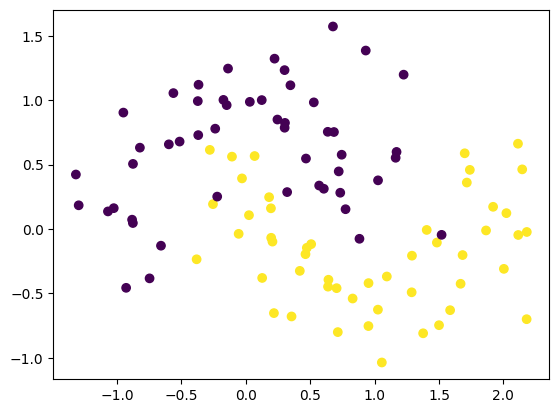

In [7]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [8]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [10]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.get_weights()

[array([[-0.76036423, -2.0468094 ,  0.05451147,  1.3835238 , -1.7383386 ,
          0.03120923,  0.04469706, -0.4492504 , -0.6227809 , -0.05879794],
        [-1.4720864 , -0.9092013 ,  1.2051944 , -1.035986  , -0.27299324,
         -0.0837964 ,  0.75700295, -0.7297163 ,  1.5871675 , -0.04373909]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.38356653,  0.8255412 ,  0.00967618, -0.29043892, -0.0933346 ,
          0.5338021 ,  0.25170127,  0.17754345, -0.48871854, -0.28369126],
        [-0.5389978 , -0.37153   , -0.32242608, -0.75928926, -0.81249875,
         -0.15949585, -0.1825737 ,  0.9888805 ,  0.27745223,  0.19377084],
        [ 0.24735214, -0.26692358,  0.26672745, -0.74935955,  0.3260054 ,
          0.05670338,  0.3786123 ,  0.05454271,  0.23393948, -0.3482696 ],
        [-0.20301971, -0.49981013, -0.2582395 ,  0.2587971 ,  0.61149395,
          0.21388064,  0.81870925,  0.10833188, -0.25150612, -0.38140574],
        [ 0.30061

In [12]:
initial_weights = model.get_weights()

In [13]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [14]:
model.set_weights(initial_weights)

In [15]:
model.get_weights()

[array([[-0.08866634,  0.3170749 , -0.24538812, -0.5660751 ,  0.24922521,
         -1.3070573 ,  1.0613729 ,  0.28158027,  1.7785143 , -1.0321084 ],
        [-0.8111095 ,  0.84920156, -0.7606604 , -1.2803886 ,  0.7906984 ,
         -0.46633404, -1.042258  ,  0.46214446,  0.51656395, -0.53831005]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.18120724,  0.2675726 ,  0.05872199, -0.06658421,  0.42243978,
          0.44985762,  0.6056068 , -0.30209738, -0.31780466,  0.55850565],
        [-0.10742313, -0.32433033, -0.16625962,  0.32343626,  0.1720192 ,
          0.2990489 ,  0.22328879, -0.04820489, -0.4808552 , -0.11509395],
        [ 0.5067605 ,  0.1395199 ,  0.93711597, -0.49136823, -0.14759748,
         -0.05830773, -0.3249752 ,  0.17662264, -0.31791025,  0.4024487 ],
        [ 0.33880374,  0.26505116, -0.1867133 , -0.09103995,  0.05586478,
         -0.28378242,  0.28427115,  0.06605335, -0.14573525, -0.18762387],
        [-0.32528

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.4727 - loss: 0.7017 - val_accuracy: 0.5000 - val_loss: 0.7027
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4609 - loss: 0.6981 - val_accuracy: 0.4500 - val_loss: 0.6984
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4844 - loss: 0.6915 - val_accuracy: 0.4500 - val_loss: 0.6945
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4727 - loss: 0.6887 - val_accuracy: 0.4500 - val_loss: 0.6908
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4914 - loss: 0.6832 - val_accuracy: 0.4500 - val_loss: 0.6872
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5148 - loss: 0.6775 - val_accuracy: 0.4500 - val_loss: 0.6835
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5055 - loss: 0.6745 - val_accuracy: 0.4500 - val_loss: 0.6794
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4602 - loss: 0.6727 - val_accuracy: 0.5000 - val_loss

In [18]:
model.get_weights()

[array([[ 0.01396666,  0.24618387, -0.14876594, -0.42835432,  0.29371774,
         -1.4072642 ,  1.2100239 ,  0.18242888,  1.9695337 , -1.2400583 ],
        [-1.0187557 ,  0.881873  , -0.9775391 , -1.5377383 ,  0.9273914 ,
         -0.40380907, -1.2360505 ,  0.56494445,  0.43789905, -0.35354868]],
       dtype=float32),
 array([ 0.18638125,  0.15722328,  0.17268424,  0.2619749 ,  0.00602362,
        -0.13314246,  0.04042408,  0.03024549,  0.04249021,  0.03813594],
       dtype=float32),
 array([[ 0.2786162 ,  0.4351959 ,  0.23615572,  0.00850919,  0.61913204,
          0.41523722,  0.46131104, -0.21447341, -0.22463658,  0.6788204 ],
        [-0.08863792, -0.35504866, -0.24800424,  0.44987166,  0.1362656 ,
          0.47096086,  0.19322959, -0.08671974, -0.31873593, -0.20599705],
        [ 0.66926193,  0.37169334,  1.1460997 , -0.43177813,  0.03959388,
         -0.2828623 , -0.46619192,  0.27544323, -0.2405923 ,  0.5139113 ],
        [ 0.50882506,  0.506125  , -0.06546219, -0.02197162, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

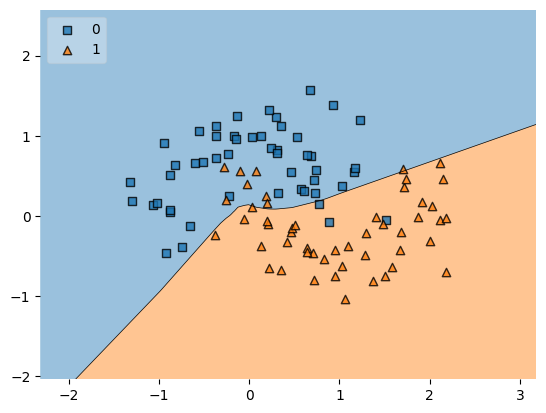

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [20]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.022633488349277107)

In [21]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.02685263106788507)